# Exploratory Data Analysis (EDA) & Data Preparation - Skripsi

Notebook ini berfungsi secara khusus sebagai lampiran akademis untuk Bab 3 dan Bab 4 Skripsi. Notebook ini tidak terhubung dan tidak mempengaruhi sistem utama yang dideploy di Streamlit.

Tujuan utama notebook ini adalah untuk membuktikan secara formal proses inspeksi data, pencarian nilai kosong, pengecekan duplikat, statistika deskriptif, dan simulasi proses Data Preparation.

## 1. Import Library

In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

## 2. Memuat Data
Membaca data historis saham BBCA dari file CSV cadangan yang sudah tersedia.

In [3]:
# Membaca data CSV
df = pd.read_csv('bbca_cadangan.csv')

# Mengubah tipe kolom Date menjadi datetime
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Date,Close,High,Low,Open,Volume
0,2016-03-31,2100.871826,2104.820833,2081.126790,2096.922819,107951000
1,2016-04-01,2100.871826,2104.820833,2085.075797,2100.871826,73802500
2,2016-04-04,2104.821045,2120.617075,2100.872037,2120.617075,49630500
3,2016-04-05,2104.821045,2124.566083,2100.872037,2104.821045,83700500
4,2016-04-06,2061.381592,2120.616695,2061.381592,2100.871661,89264000


In [4]:
df.tail()

,Date,Close,High,Low,Open,Volume
2455,2026-03-17,6490.854492,6538.757477,6466.903000,6466.903000,160903900
2456,2026-03-25,6610.612305,6634.563799,6395.048860,6395.048860,314281100
2457,2026-03-26,6586.660645,6682.466618,6562.709151,6610.612138,145934900
2458,2026-03-27,6419.000000,6562.708955,6419.000000,6490.854478,283556500
2459,2026-03-30,6450.000000,6500.000000,6350.000000,6400.000000,242278100


## 3. Pengecekan Informasi dan Tipe Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2460 non-null   datetime64[ns]
 1   Close   2460 non-null   float64       
 2   High    2460 non-null   float64       
 3   Low     2460 non-null   float64       
 4   Open    2460 non-null   float64       
 5   Volume  2460 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 115.4 KB


## 4. Pengecekan Data Kosong (Missing Values)

In [6]:
print("Jumlah Data Kosong pada setiap kolom:")
df.isnull().sum()

Jumlah Data Kosong pada setiap kolom:


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## 5. Pengecekan Data Duplikat

In [7]:
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris data yang terduplikasi: {jumlah_duplikat}")

Jumlah baris data yang terduplikasi: 0


## 6. Describe

In [8]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,2460,2460.000000,2460.000000,2460.000000,2460.000000,2.460000e+03
mean,2021-02-28 18:49:10.243902464,5741.608708,5794.075988,5690.732787,5742.788803,8.945250e+07
min,2016-03-31 00:00:00,2034.310669,2042.272787,2010.424438,2014.405517,0.000000e+00
25%,2018-09-02 06:00:00,3867.207581,3908.668730,3827.996723,3864.843167,5.560182e+07
50%,2021-02-13 00:00:00,5515.328613,5560.126525,5472.423491,5525.019045,7.555940e+07
75%,2023-08-24 06:00:00,7756.506226,7832.138498,7688.429534,7768.732565,1.042561e+08
max,2026-03-30 00:00:00,10060.582031,10060.582031,9899.796260,10014.642719,1.432993e+09
std,NaN,2163.853474,2182.925787,2147.228358,2164.437017,7.194273e+07


In [9]:
df.shape

(2460, 6)

## 7. Visualisasi Tren Data Historis

In [10]:
fig_trend = go.Figure()
fig_trend.add_trace(go.Scatter(
    x=df['Date'], 
    y=df['Close'], 
    name="Harga Penutupan (Close)", 
    line_color='deepskyblue'
))
fig_trend.update_layout(
    title="Grafik Historis Pergerakan Harga Saham BBCA (2016-2026)", 
    xaxis_title="Tanggal",
    yaxis_title="Harga (Rupiah)"
)
fig_trend.show()

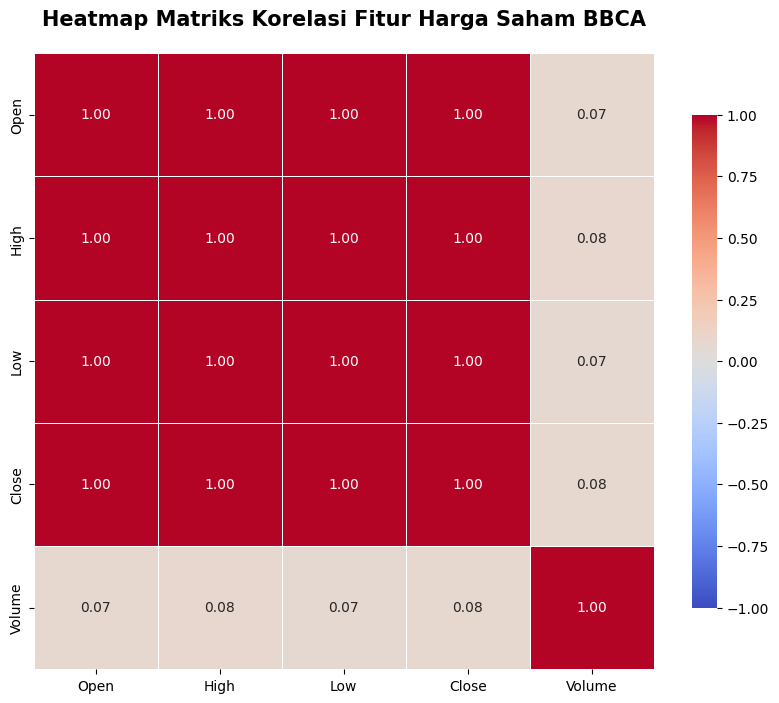

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Memilih hanya kolom numerik
kolom_numerik = df[['Open', 'High', 'Low', 'Close', 'Volume']]

# Menghitung nilai matriks korelasi 
matriks_korelasi = kolom_numerik.corr()

# Visualiasi heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriks_korelasi, 
            annot=True,               
            cmap='coolwarm',          
            fmt='.2f',                
            linewidths=0.5,           
            vmin=-1, vmax=1,          
            cbar_kws={"shrink": .8})  
plt.title('Heatmap Matriks Korelasi Fitur Harga Saham BBCA', fontsize=15, fontweight='bold', pad=20)
plt.show()

## 8. Pengecekan Outlier

In [12]:
fig_outlier = px.box(df, y='Close', title='Boxplot Harga Penutupan Saham BBCA (Deteksi Outlier)')
fig_outlier.update_layout(yaxis_title="Harga (Rupiah)")
fig_outlier.show()

## 9. Simulasi Data Preparation 

In [13]:
print("TAHAPAN DATA PREPARATION\n")

# Pemisahan Data (80% Latih, 20% Uji)
total_data = len(df)
train_size = int(total_data * 0.8)
test_size = total_data - train_size
print(f"1. Data Splitting 80/20:")
print(f"- Total Keseluruhan Data : {total_data} baris")
print(f"- Total Data Latih (80%) : {train_size} baris (digunakan untuk training)")
print(f"- Total Data Uji (20%)   : {test_size} baris (digunakan untuk evaluasi/testing)\n")

# Normalisasi Data untuk LSTM (MinMaxScaler)
scaler = MinMaxScaler(feature_range=(0, 1))
data_close = df[['Close']].values
scaled_data = scaler.fit_transform(data_close)
print("Normalisasi Data untuk LSTM (MinMaxScaler):")
print("Tujuan: Mengubah skala ratusan ribu Rupiah menjadi angka rentang 0 hingga 1 agar LSTM lebih cepat belajar.")
print("- 5 Baris Awal Harga Asli (Rp) :", data_close[:5].flatten())
print("- 5 Baris Awal Harga Normalisasi :", scaled_data[:5].flatten(), "\n")

# Penyesuaian Nama Atribut untuk Facebook Prophet
df_prophet = df[['Date', 'Close']].copy()
df_prophet.rename(columns={'Date': 'ds', 'Close': 'y'}, inplace=True)
print("Penyesuaian Nama Atribut untuk Facebook Prophet:")
print("Tujuan: Menyesuaikan nama kolom sesuai dengan standar wajib algoritma Prophet.")
print("- Tampilan kolom setelah diubah (Date -> ds, Close -> y):")
print(df_prophet.head())

TAHAPAN DATA PREPARATION

1. Data Splitting 80/20:
- Total Keseluruhan Data : 2460 baris
- Total Data Latih (80%) : 1968 baris (digunakan untuk training)
- Total Data Uji (20%)   : 492 baris (digunakan untuk evaluasi/testing)

Normalisasi Data untuk LSTM (MinMaxScaler):
Tujuan: Mengubah skala ratusan ribu Rupiah menjadi angka rentang 0 hingga 1 agar LSTM lebih cepat belajar.
- 5 Baris Awal Harga Asli (Rp) : [2100.87182617 2100.87182617 2104.82104492 2104.82104492 2061.3815918 ]
- 5 Baris Awal Harga Normalisasi : [0.00829291 0.00829291 0.00878495 0.00878495 0.00337279] 

Penyesuaian Nama Atribut untuk Facebook Prophet:
Tujuan: Menyesuaikan nama kolom sesuai dengan standar wajib algoritma Prophet.
- Tampilan kolom setelah diubah (Date -> ds, Close -> y):
          ds            y
0 2016-03-31  2100.871826
1 2016-04-01  2100.871826
2 2016-04-04  2104.821045
3 2016-04-05  2104.821045
4 2016-04-06  2061.381592
